<a href="https://colab.research.google.com/github/MaCuur/AI_EGs/blob/main/Copia_de_Procesamiento_de_datos_REALES_lluvias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Procesamiento de datos


Código LSTM con Datos Reales (PMLDF.csv)
Este código realiza los pasos de: 1. Carga y Reestructuración, 2. Limpieza y Escalamiento, 3. Creación de Secuencias y División, 4. Definición del Modelo (con Dropout) y 5. Entrenamiento.

1. Carga, Reestructuración y Limpieza de Datos

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# --- CONFIGURACIÓN DE PARÁMETROS ---
TIMESTEPS_IN = 2 #14  # Días históricos usados para predecir (Aumentamos a 14 días)
TIMESTEPS_OUT = 5  # Días a predecir simultáneamente (Día 1, 2, 3, 4, 5)
TEST_SIZE = 0.2    # 20% de los datos para la evaluación final
EPOCHS = 100       # Número de ciclos de entrenamiento
DROPOUT_RATE = 0.2 # Tasa de Dropout

# 1. Carga del Archivo CSV
try:
    # Cargar el archivo, asumiendo que la primera fila son los encabezados (Años)
    df = pd.read_csv("/content/drive/MyDrive/estaciones_cdmx/sin_encabezado/sts_sin_st_column/st_precipitacion/sorted/PMLDF__PC_sorted.csv")
except FileNotFoundError:
    print("Error: Asegúrate de que el archivo 'PMLDF__PC.csv' esté en la ubicación correcta.")
    exit()

# 2. Reestructuración a una única Serie de Tiempo Diaria con fechas
# Melt the DataFrame to long format: 'dia_del_anio' and 'year' columns, 'precipitacion' value column
df_melted = df.melt(id_vars=['dia_del_anio'], var_name='year', value_name='precipitacion')

# Convert 'year' to numeric, handling potential errors
df_melted['year'] = pd.to_numeric(df_melted['year'], errors='coerce')
df_melted.dropna(subset=['year'], inplace=True) # Drop rows where year conversion failed
df_melted['year'] = df_melted['year'].astype(int)

# Combine 'year' and 'dia_del_anio' to create a date string (YYYY-DDD format)
df_melted['date_str'] = df_melted['year'].astype(str) + '-' + df_melted['dia_del_anio'].astype(str).str.zfill(3)

# Convert to datetime objects, coercing invalid dates (e.g., day 366 in non-leap year) to NaT
df_melted['fecha'] = pd.to_datetime(df_melted['date_str'], format='%Y-%j', errors='coerce')

# Filter out rows where date conversion failed
df_melted.dropna(subset=['fecha'], inplace=True)

# Sort by date and set 'fecha' as the DataFrame index
precipitacion_df = df_melted[['fecha', 'precipitacion']].set_index('fecha').sort_index()

print("--- Resumen de Datos Iniciales ---")
print(f"Total de registros cargados: {len(precipitacion_df)}")
print(f"Registros con valores NaN (faltantes): {precipitacion_df.isnull().sum().iloc[0]}")

# 3. Limpieza de Datos: Omitir los registros faltantes (NaN)
precipitacion_limpia = precipitacion_df.dropna() # Now precipitacion_limpia has a DateTimeIndex

# Convert to array of NumPy
datos_limpios = precipitacion_limpia.values.astype('float32')

print(f"Total de registros limpios y usados: {len(datos_limpios)}")

# 4. Escalamiento de Datos
scaler = MinMaxScaler(feature_range=(0, 1))
datos_escalados = scaler.fit_transform(datos_limpios)

print("----------------------------------")

--- Resumen de Datos Iniciales ---
Total de registros cargados: 13908
Registros con valores NaN (faltantes): 670
Total de registros limpios y usados: 13238
----------------------------------


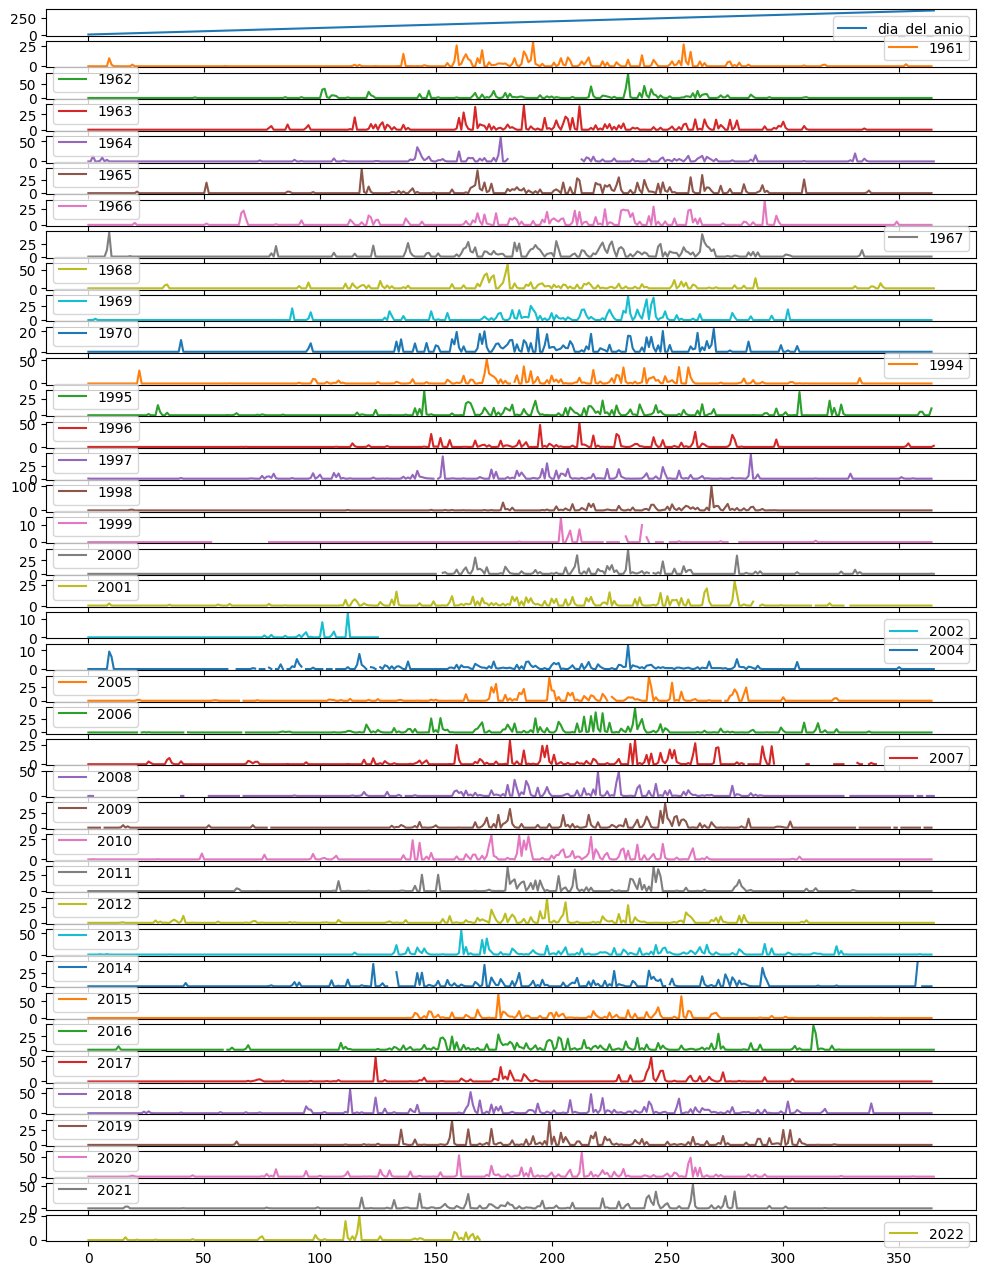

In [6]:
# Dibujemos nuestras variables
cols = df.columns

# N = 24*30*12 # Dibujar 1 año continuo
N = df.shape[0]
plots = df[cols][0:N]
plots.index = df.index[0:N]
_ = plots.plot(subplots=True, figsize=(12,16))

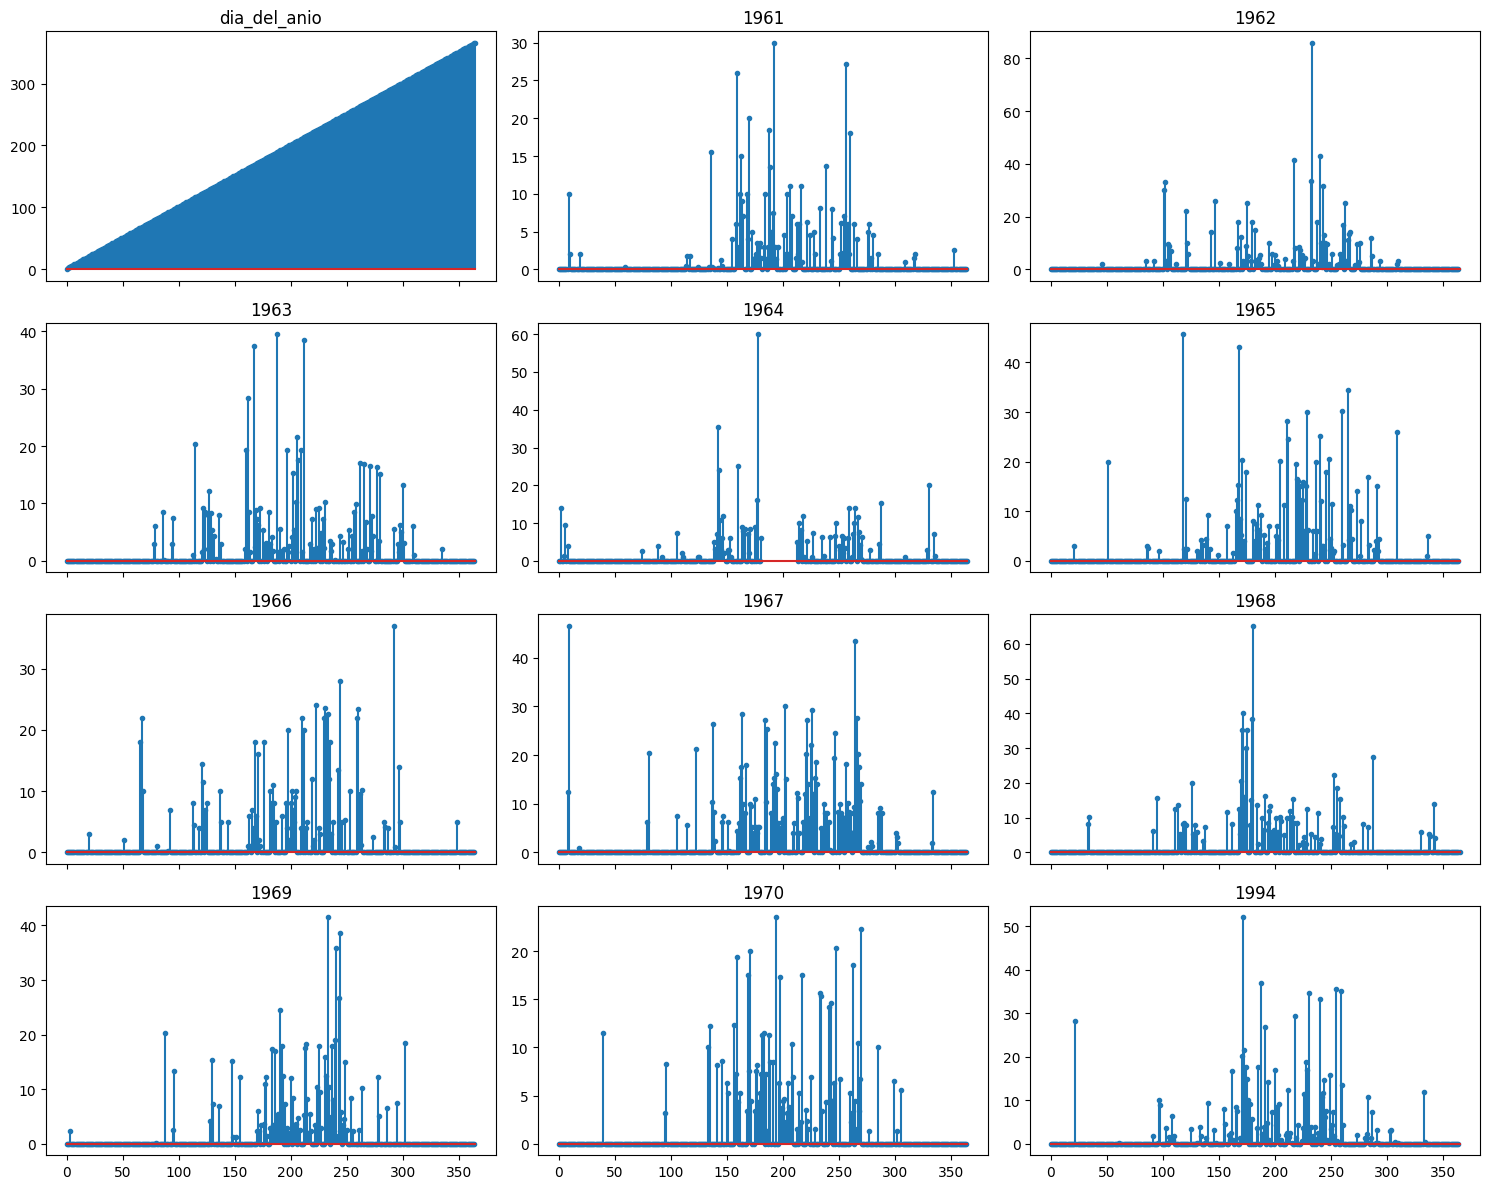

In [7]:
cols = df.columns
N = df.shape[0]
plots = df[cols].iloc[:N]

fig, axes = plt.subplots(
    nrows=4,          # ajusta según tus necesidades
    ncols=3,
    figsize=(15, 12),
    sharex=True
)

axes = axes.flatten()

for ax, col in zip(axes, cols):
    ax.stem(plots.index, plots[col],markerfmt='.',)
    ax.set_title(col)

plt.tight_layout()
plt.show()

array([[<Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >]], dtype=object)

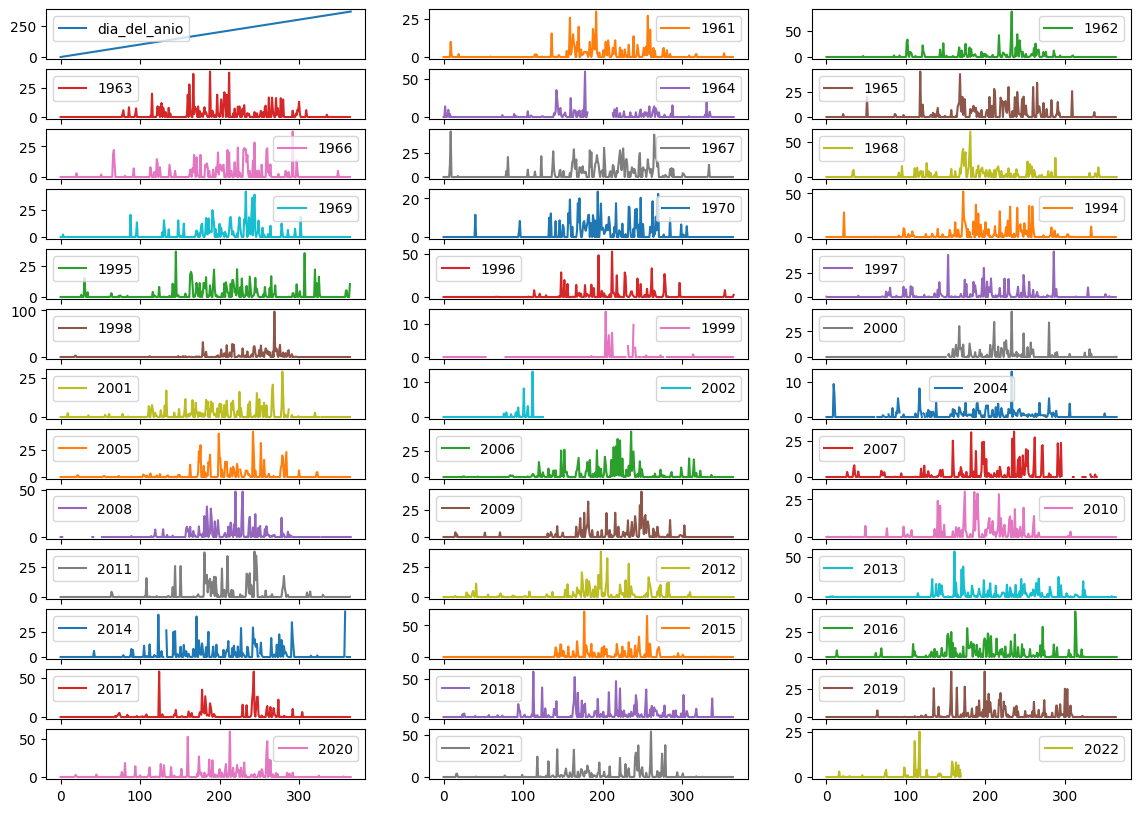

In [8]:
cols = df.columns
N = df.shape[0]
plots = df[cols].iloc[:N]

# For example, 3 columns and automatic number of rows
plots.plot(
    subplots=True,
    layout=(-1, 3),    # auto rows, 3 columns
    figsize=(14, 10),
    sharex=True
)

2. Creación de Secuencias y División de Conjuntos

In [9]:
# Función para crear las secuencias de entrada (X) y salida (y)
def crear_secuencias(datos, n_input, n_output):
    X, y = list(), list()
    for i in range(len(datos)):
        end_ix = i + n_input
        out_end_ix = end_ix + n_output

        if out_end_ix > len(datos):
            break

        seq_x = datos[i:end_ix, 0]
        seq_y = datos[end_ix:out_end_ix, 0]

        X.append(seq_x)
        y.append(seq_y)
    return np.array(X), np.array(y)

# Aplicar la función de secuencias
X, y = crear_secuencias(datos_escalados, TIMESTEPS_IN, TIMESTEPS_OUT)

# Reshape para la entrada LSTM: [muestras, timesteps, features]
X = X.reshape((X.shape[0], X.shape[1], 1))

# División Temporal en Entrenamiento, Validación y Prueba
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, shuffle=False
)
# Usar el 10% del conjunto de entrenamiento para validación
VAL_SIZE = 0.1 / (1 - TEST_SIZE) # Ajuste de tamaño
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=VAL_SIZE, shuffle=False
)

print(f"Muestras de Entrenamiento: {len(X_train)}")
print(f"Muestras de Validación: {len(X_val)}")
print(f"Muestras de Prueba: {len(X_test)}")
print("----------------------------------")

Muestras de Entrenamiento: 9261
Muestras de Validación: 1324
Muestras de Prueba: 2647
----------------------------------


3. Definición, Entrenamiento y Evaluación del Modelo

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


--- Iniciando Entrenamiento (100 Épocas) ---
Entrenamiento completado.
----------------------------------
--- Evaluación de Rendimiento (RMSE en mm) ---
**Día 1**: 5.990 mm
**Día 3**: 6.150 mm
**Día 5**: 6.126 mm


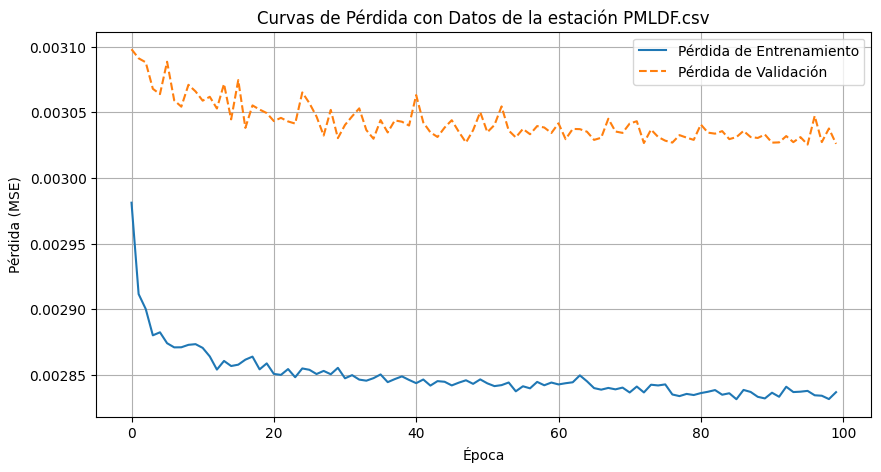


**Nota:** Para la gráfica de Predicción vs. Real, necesitaríamos más épocas y un set de datos más grande para obtener una visualización significativa.


In [10]:
from sklearn.metrics import mean_squared_error
import math

# 1. Definición del Modelo LSTM Apilado con Dropout
model = Sequential()
model.add(
    LSTM(100, activation='relu', input_shape=(TIMESTEPS_IN, 1), return_sequences=True)
)
model.add(Dropout(DROPOUT_RATE))
model.add(
    LSTM(50, activation='relu', return_sequences=False)
)
model.add(Dropout(DROPOUT_RATE))
model.add(Dense(TIMESTEPS_OUT))
model.compile(optimizer='adam', loss='mse')


# 2. Entrenamiento del Modelo
print(f"--- Iniciando Entrenamiento ({EPOCHS} Épocas) ---")
history = model.fit(
    X_train,
    y_train,
    epochs=EPOCHS,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=0
)
print("Entrenamiento completado.")
print("----------------------------------")

# 3. Evaluación en el Conjunto de Prueba
y_pred_escalada = model.predict(X_test, verbose=0)

# 4. Invertir el escalamiento
y_test_original = scaler.inverse_transform(y_test)
y_pred_original = scaler.inverse_transform(y_pred_escalada)

# 5. Cálculo y Presentación de RMSE (para Días 1, 3 y 5)
indices = {"Día 1": 0, "Día 3": 2, "Día 5": 4}

print("--- Evaluación de Rendimiento (RMSE en mm) ---")
for horizonte, idx in indices.items():
    # Calcular RMSE
    rmse = math.sqrt(mean_squared_error(y_test_original[:, idx], y_pred_original[:, idx]))
    print(f"**{horizonte}**: {rmse:.3f} mm")

# 6. Gráfica de Pérdida (para diagnóstico de Overfitting)
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Pérdida de Entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de Validación', linestyle='--')
plt.title('Curvas de Pérdida con Datos de la estación PMLDF.csv')
plt.xlabel('Época')
plt.ylabel('Pérdida (MSE)')
plt.legend()
plt.grid(True)
plt.show()


print("\n**Nota:** Para la gráfica de Predicción vs. Real, necesitaríamos más épocas y un set de datos más grande para obtener una visualización significativa.")

Este código utiliza tu archivo CSV real para predecir la precipitación acumulada diaria en los horizontes de 1, 3 y 5 días.El siguiente paso lógico, después de revisar el RMSE y la curva de pérdida, es aplicar la mejor técnica de mejora de rendimiento que discutimos (por ejemplo, Early Stopping, el uso de datos multivariados o el ajuste de $T_{in}$).

🛑 Implementación de Parada Temprana (Early Stopping)
El siguiente código retoma el paso de entrenamiento del ejemplo anterior e introduce el callback EarlyStopping.

1. Definición del Callback
Definimos los parámetros clave:

monitor='val_loss': La métrica que queremos monitorear (la pérdida en el conjunto de validación).

patience=15: El número de épocas que el modelo esperará sin que haya una mejora en val_loss antes de detenerse.

restore_best_weights=True: Vuelve a cargar los pesos del modelo que logró el mejor rendimiento en la pérdida de validación.

2. Código Actualizado para el Entrenamiento
Continuamos desde donde se generaron los conjuntos de datos (X_train, y_train, X_val, y_val).

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


--- Iniciando Entrenamiento (Máx 200 Épocas con Early Stopping) ---
La paciencia (patience) es de 15 épocas sin mejora en val_loss.
Epoch 23: early stopping
Restoring model weights from the end of the best epoch: 8.
Entrenamiento completado y detenido en la época: 23
----------------------------------


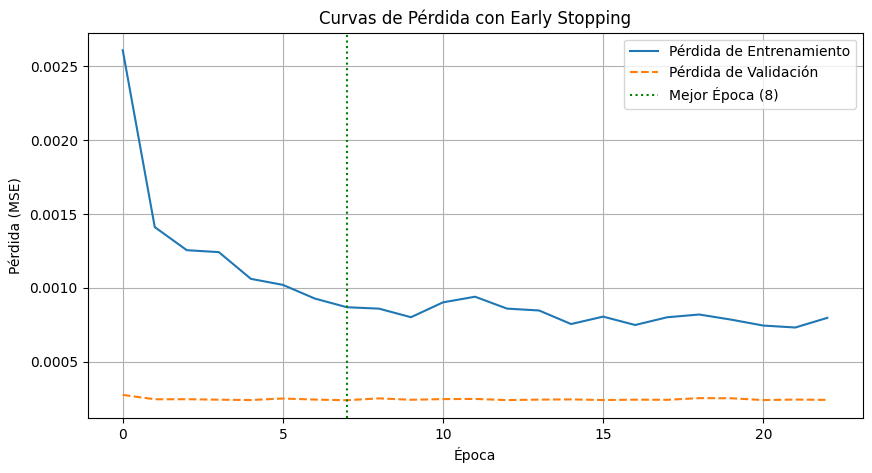

In [11]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error
import math
import matplotlib.pyplot as plt

# --- CONFIGURACIÓN DE PARÁMETROS ---
TIMESTEPS_IN = 14
TIMESTEPS_OUT = 5
TEST_SIZE = 0.2
EPOCHS = 200      # Aumentamos las épocas máximas, ya que Early Stopping nos detendrá
DROPOUT_RATE = 0.2
PATIENCE = 15     # Parámetro de Early Stopping

# --- RE-DEFINICIÓN DE VARIABLES DE DATOS PARA ASEGURAR EL CONTEXTO ---
# 1. Carga del Archivo CSV (repetido para asegurar disponibilidad)
try:
    df = pd.read_csv("/content/drive/MyDrive/estaciones_cdmx/sin_encabezado/sts_sin_st_column/st_precipitacion/sorted/PMLDF__PC_sorted.csv") # Corrected filename
except FileNotFoundError:
    print("Error: Asegúrate de que el archivo 'C09002_PC_sorted.csv' esté en la ubicación correcta.")
    exit()

# 2. Reestructuración a una única Serie de Tiempo Diaria
precipitacion_serie = df.unstack().reset_index(drop=True).rename('Precipitacion')
precipitacion_df = pd.DataFrame(precipitacion_serie)

# 3. Limpieza de Datos: Omitir los registros faltantes (NaN)
precipitacion_limpia = precipitacion_df.dropna()
datos_limpios = precipitacion_limpia.values.astype('float32')

# 4. Escalamiento de Datos
scaler = MinMaxScaler(feature_range=(0, 1))
datos_escalados = scaler.fit_transform(datos_limpios)

# Función para crear las secuencias de entrada (X) y salida (y) (repetido)
def crear_secuencias(datos, n_input, n_output):
    X_seq, y_seq = list(), list()
    for i in range(len(datos)):
        end_ix = i + n_input
        out_end_ix = end_ix + n_output

        if out_end_ix > len(datos):
            break

        seq_x = datos[i:end_ix, 0]
        seq_y = datos[end_ix:out_end_ix, 0]

        X_seq.append(seq_x)
        y_seq.append(seq_y)
    return np.array(X_seq), np.array(y_seq)

# Aplicar la función de secuencias
X, y = crear_secuencias(datos_escalados, TIMESTEPS_IN, TIMESTEPS_OUT)

# Reshape para la entrada LSTM: [muestras, timesteps, features]
X = X.reshape((X.shape[0], X.shape[1], 1))

# División Temporal en Entrenamiento, Validación y Prueba
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, shuffle=False
)
VAL_SIZE = 0.1 / (1 - TEST_SIZE) # Ajuste de tamaño
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=VAL_SIZE, shuffle=False
)
# --- FIN DE RE-DEFINICIÓN DE VARIABLES DE DATOS ---

# 1. Definición del Modelo (Mismo modelo LSTM Apilado con Dropout)
model = Sequential()
model.add(LSTM(100, activation='relu', input_shape=(TIMESTEPS_IN, 1), return_sequences=True))
model.add(Dropout(DROPOUT_RATE))
model.add(LSTM(50, activation='relu', return_sequences=False))
model.add(Dropout(DROPOUT_RATE))
model.add(Dense(TIMESTEPS_OUT))
model.compile(optimizer='adam', loss='mse')

# ----------------------------------------------------
# 2. Implementación de Parada Temprana (Early Stopping)
# ----------------------------------------------------
early_stopping = EarlyStopping(
    monitor='val_loss',         # Métrica a monitorear
    patience=PATIENCE,          # Número de épocas sin mejora antes de parar
    restore_best_weights=True,  # Cargar los mejores pesos encontrados
    verbose=1                   # Muestra un mensaje cuando se detiene
)

# 3. Entrenamiento del Modelo con el Callback
print(f"--- Iniciando Entrenamiento (Máx {EPOCHS} Épocas con Early Stopping) ---")
print(f"La paciencia (patience) es de {PATIENCE} épocas sin mejora en val_loss.")

history = model.fit(
    X_train,
    y_train,
    epochs=EPOCHS,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping], # AÑADIMOS EL CALLBACK AQUÍ
    verbose=0
)

# El entrenamiento se detendrá automáticamente cuando se cumpla la condición de Early Stopping.
final_epoch = len(history.history['loss'])
print(f"Entrenamiento completado y detenido en la época: {final_epoch}")
print("----------------------------------")

# 4. Gráfica de Pérdida
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Pérdida de Entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de Validación', linestyle='--')

# Calcular la mejor época para la línea vertical
best_epoch_idx = np.argmin(history.history['val_loss'])
plt.axvline(x=best_epoch_idx, color='green', linestyle=':', label=f'Mejor Época ({best_epoch_idx + 1})')

plt.title('Curvas de Pérdida con Early Stopping')
plt.xlabel('Época')
plt.ylabel('Pérdida (MSE)')
plt.legend()
plt.grid(True)
plt.show()


# 5. Evaluación Final (Opcional, pero esencial para el rendimiento)
# (Aquí iría el código de predicción e inversión de escalamiento para calcular el RMSE en X_test)

Al utilizar EarlyStopping, el modelo se detendrá tan pronto como el rendimiento en el conjunto de validación ya no mejore significativamente. Esto no solo previene el sobreajuste, sino que también garantiza que tu modelo final utiliza los pesos que mejor generalizan.

5. Evaluación Final (Predicción e Inversión de Escalamiento)
Este bloque de código debe ejecutarse después de que el modelo haya sido entrenado y detenido por el Early Stopping.

In [12]:
# --- Asumiendo que el modelo (model) ha sido entrenado y las variables de prueba
# (X_test, y_test) y el escalador (scaler) están disponibles ---

# 1. Predicción sobre el conjunto de prueba (Test Set)
print("--- Iniciando Evaluación Final sobre X_test ---")
y_pred_escalada = model.predict(X_test, verbose=0)

# 2. Invertir el escalamiento para las predicciones y los valores reales de prueba
# Esto devuelve los datos a la escala original (mm de precipitación)
try:
    y_test_original = scaler.inverse_transform(y_test)
    y_pred_original = scaler.inverse_transform(y_pred_escalada)
except AttributeError:
    # Esto puede ocurrir si el scaler no fue ajustado correctamente en los pasos previos
    print("\nError: El objeto 'scaler' no está disponible o no fue ajustado (fit) correctamente.")
    print("Asegúrate de ejecutar las secciones 1 y 2 completas para cargar y escalar los datos.")
    exit()

# 3. Cálculo y Presentación de RMSE (para Días 1, 3 y 5)
indices = {
    "Día 1": 0,  # Índice 0 de la salida de 5 días
    "Día 3": 2,  # Índice 2 de la salida de 5 días
    "Día 5": 4   # Índice 4 de la salida de 5 días
}

print("\n--- Resultados de Rendimiento (RMSE en mm) ---")

for horizonte, idx in indices.items():
    # Extraer los datos para el horizonte específico
    y_test_horizonte = y_test_original[:, idx]
    y_pred_horizonte = y_pred_original[:, idx]

    # Calcular RMSE (Raíz del Error Cuadrático Medio)
    mse = mean_squared_error(y_test_horizonte, y_pred_horizonte)
    rmse = math.sqrt(mse)

    print(f"**{horizonte}** a futuro:")
    print(f"  RMSE: {rmse:.3f} mm")

print("\n**Interpretación:** El RMSE indica el error promedio del pronóstico en la unidad original (mm).")

--- Iniciando Evaluación Final sobre X_test ---

--- Resultados de Rendimiento (RMSE en mm) ---
**Día 1** a futuro:
  RMSE: 6.075 mm
**Día 3** a futuro:
  RMSE: 6.131 mm
**Día 5** a futuro:
  RMSE: 6.103 mm

**Interpretación:** El RMSE indica el error promedio del pronóstico en la unidad original (mm).


In [13]:
from sklearn.metrics import r2_score
import numpy as np

def nash_sutcliffe_efficiency(y_true, y_pred):
    numerator = np.sum((y_true - y_pred)**2)
    denominator = np.sum((y_true - np.mean(y_true))**2)
    if denominator == 0:
        return np.nan # Avoid division by zero if all true values are the same
    return 1 - (numerator / denominator)

# --- Assuming y_test_original and y_pred_original are available from the previous cell ---

indices = {
    "Día 1": 0,  # Índice 0 de la salida de 5 días
    "Día 3": 2,  # Índice 2 de la salida de 5 días
    "Día 5": 4   # Índice 4 de la salida de 5 días
}

print("\n--- Métricas Adicionales (NSE y R²) ---")

for horizonte, idx in indices.items():
    y_test_horizonte = y_test_original[:, idx]
    y_pred_horizonte = y_pred_original[:, idx]

    # Calcular NSE
    nse = nash_sutcliffe_efficiency(y_test_horizonte, y_pred_horizonte)

    # Calcular R-squared
    r2 = r2_score(y_test_horizonte, y_pred_horizonte)

    print(f"**{horizonte}** a futuro:")
    print(f"  NSE: {nse:.3f}")
    print(f"  R²: {r2:.3f}")

print("\n**Interpretación:**\n- **NSE (Nash-Sutcliffe Efficiency):** Mide qué tan bien la gráfica de los valores observados frente a los simulados se ajusta a la línea 1:1. Un valor de 1 indica un ajuste perfecto, 0 indica que el modelo no es mejor que la media de los datos observados, y valores negativos indican que el modelo es peor que la media.\n- **R² (Coeficiente de Determinación):** Indica la proporción de la varianza en la variable dependiente que es predecible a partir de la variable(s) independiente(s). Un valor de 1 indica que el modelo predice perfectamente la varianza, mientras que un valor de 0 indica que el modelo no explica ninguna de la variabilidad de la respuesta alrededor de su media.")


--- Métricas Adicionales (NSE y R²) ---
**Día 1** a futuro:
  NSE: 0.031
  R²: 0.031
**Día 3** a futuro:
  NSE: 0.013
  R²: 0.013
**Día 5** a futuro:
  NSE: 0.022
  R²: 0.022

**Interpretación:**
- **NSE (Nash-Sutcliffe Efficiency):** Mide qué tan bien la gráfica de los valores observados frente a los simulados se ajusta a la línea 1:1. Un valor de 1 indica un ajuste perfecto, 0 indica que el modelo no es mejor que la media de los datos observados, y valores negativos indican que el modelo es peor que la media.
- **R² (Coeficiente de Determinación):** Indica la proporción de la varianza en la variable dependiente que es predecible a partir de la variable(s) independiente(s). Un valor de 1 indica que el modelo predice perfectamente la varianza, mientras que un valor de 0 indica que el modelo no explica ninguna de la variabilidad de la respuesta alrededor de su media.


In [14]:
from sklearn.metrics import mean_absolute_error
import numpy as np

def mean_absolute_percentage_error(y_true, y_pred):
    # Avoid division by zero by replacing 0s in y_true with a small epsilon
    epsilon = np.finfo(np.float64).eps
    return np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, epsilon))) * 100

def symmetric_mean_absolute_percentage_error(y_true, y_pred):
    numerator = np.abs(y_pred - y_true)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    # Avoid division by zero
    return np.mean(np.where(denominator == 0, 0, numerator / denominator)) * 100

def percent_bias(y_true, y_pred):
    # Avoid division by zero
    if np.sum(y_true) == 0:
        return np.nan
    return np.sum(y_pred - y_true) / np.sum(y_true) * 100

# --- Assuming y_test_original and y_pred_original are available ---

indices = {
    "Día 1": 0,  # Índice 0 de la salida de 5 días
    "Día 3": 2,  # Índice 2 de la salida de 5 días
    "Día 5": 4   # Índice 4 de la salida de 5 días
}

print("\n--- Métricas de Error Adicionales ---")

for horizonte, idx in indices.items():
    y_test_horizonte = y_test_original[:, idx]
    y_pred_horizonte = y_pred_original[:, idx]

    # Calcular MAE
    mae = mean_absolute_error(y_test_horizonte, y_pred_horizonte)

    # Calcular MAPE
    mape = mean_absolute_percentage_error(y_test_horizonte, y_pred_horizonte)

    # Calcular sMAPE
    smape = symmetric_mean_absolute_percentage_error(y_test_horizonte, y_pred_horizonte)

    # Calcular PBIAS
    pbias = percent_bias(y_test_horizonte, y_pred_horizonte)

    print(f"**{horizonte}** a futuro:")
    print(f"  MAE: {mae:.3f} mm")
    print(f"  MAPE: {mape:.2f}%")
    print(f"  sMAPE: {smape:.2f}%")
    print(f"  PBIAS: {pbias:.2f}%")

print("\n**Interpretación de las Métricas:**\n- **MAE (Mean Absolute Error):** Es el promedio de la magnitud de los errores en un conjunto de predicciones, sin considerar su dirección. Se expresa en las mismas unidades que la variable pronosticada (mm).\n- **MAPE (Mean Absolute Percentage Error):** Mide el tamaño del error en términos porcentuales. Es sensible a valores cero o cercanos a cero en los datos reales (y_true), lo que puede generar valores muy grandes o infinitos. Aquí se ha ajustado para manejar ceros.\n- **sMAPE (Symmetric Mean Absolute Percentage Error):** Similar a MAPE pero intenta ser más simétrico con respecto a la subestimación y sobrestimación, dividiendo el error por el promedio de los valores reales y pronosticados. También se expresa en porcentaje.\n- **PBIAS (Percent Bias):** Indica la tendencia promedio de la predicción a ser mayor o menor que el valor real. Un valor positivo indica una sobrestimación (el modelo predice más de lo real), mientras que un valor negativo indica una subestimación (el modelo predice menos de lo real). Se expresa en porcentaje.")


--- Métricas de Error Adicionales ---
**Día 1** a futuro:
  MAE: 3.009 mm
  MAPE: 605085948323264000.00%
  sMAPE: 170.97%
  PBIAS: -1.80%
**Día 3** a futuro:
  MAE: 3.600 mm
  MAPE: 883213844793396096.00%
  sMAPE: 170.24%
  PBIAS: 40.90%
**Día 5** a futuro:
  MAE: 2.922 mm
  MAPE: 558679257766907584.00%
  sMAPE: 171.15%
  PBIAS: -10.03%

**Interpretación de las Métricas:**
- **MAE (Mean Absolute Error):** Es el promedio de la magnitud de los errores en un conjunto de predicciones, sin considerar su dirección. Se expresa en las mismas unidades que la variable pronosticada (mm).
- **MAPE (Mean Absolute Percentage Error):** Mide el tamaño del error en términos porcentuales. Es sensible a valores cero o cercanos a cero en los datos reales (y_true), lo que puede generar valores muy grandes o infinitos. Aquí se ha ajustado para manejar ceros.
- **sMAPE (Symmetric Mean Absolute Percentage Error):** Similar a MAPE pero intenta ser más simétrico con respecto a la subestimación y sobrestimación

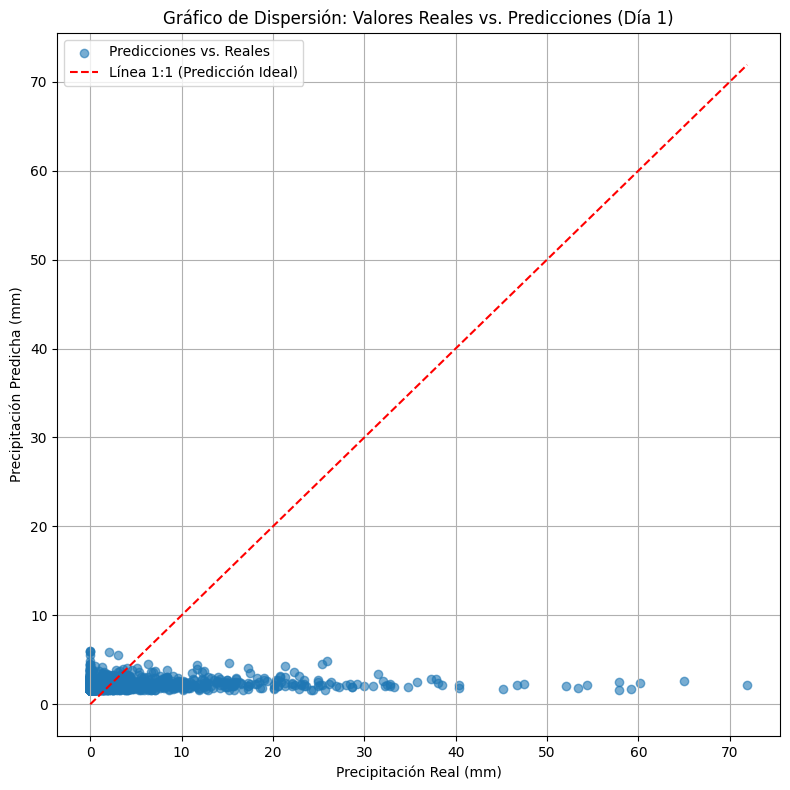

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# --- Asumiendo que las variables y_test_original y y_pred_original ya fueron calculadas ---
# y_test_original.shape = (muestras_test, 5)
# y_pred_original.shape = (muestras_test, 5)

# 1. Seleccionar el horizonte de interés (Día 1)
HORIZONTE_INDEX_SCATTER = 0  # Índice 0 corresponde al Día 1 a futuro

y_test_scatter = y_test_original[:, HORIZONTE_INDEX_SCATTER]
y_pred_scatter = y_pred_original[:, HORIZONTE_INDEX_SCATTER]

# 2. Generar el gráfico de dispersión
plt.figure(figsize=(8, 8))
plt.scatter(y_test_scatter, y_pred_scatter, alpha=0.6, label='Predicciones vs. Reales')

# 3. Añadir la línea 1:1 (ideal)
min_val = min(y_test_scatter.min(), y_pred_scatter.min())
max_val = max(y_test_scatter.max(), y_pred_scatter.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Línea 1:1 (Predicción Ideal)')

plt.title('Gráfico de Dispersión: Valores Reales vs. Predicciones (Día 1)')
plt.xlabel('Precipitación Real (mm)')
plt.ylabel('Precipitación Predicha (mm)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [16]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import math

# Re-define metric functions to ensure they are available for this cell
def nash_sutcliffe_efficiency(y_true, y_pred):
    numerator = np.sum((y_true - y_pred)**2)
    denominator = np.sum((y_true - np.mean(y_true))**2)
    if denominator == 0:
        return np.nan # Avoid division by zero if all true values are the same
    return 1 - (numerator / denominator)

def mean_absolute_percentage_error(y_true, y_pred):
    epsilon = np.finfo(np.float64).eps
    return np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, epsilon))) * 100

def symmetric_mean_absolute_percentage_error(y_true, y_pred):
    numerator = np.abs(y_pred - y_true)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    return np.mean(np.where(denominator == 0, 0, numerator / denominator)) * 100

def percent_bias(y_true, y_pred):
    if np.sum(y_true) == 0:
        return np.nan
    return np.sum(y_pred - y_true) / np.sum(y_true) * 100

# --- Implementación del Modelo Base (Persistente/Naive) ---
# El modelo persistente predice que los próximos TIMESTEPS_OUT valores
# serán iguales al último valor observado en la secuencia de entrada (TIMESTEPS_IN).

# Extraer el último valor de cada secuencia de entrada de X_test
# X_test tiene forma (muestras, TIMESTEPS_IN, 1)
last_observed_values_escalados = X_test[:, -1, 0] # Tomar el último valor de cada secuencia

# Crear las predicciones del modelo base en escala escalada
# Cada predicción de TIMESTEPS_OUT días será el último valor observado
y_pred_baseline_escalada = np.tile(last_observed_values_escalados, (TIMESTEPS_OUT, 1)).T

# Invertir el escalamiento de las predicciones del modelo base
y_pred_baseline_original = scaler.inverse_transform(y_pred_baseline_escalada)

# --- Comparación de Métricas ---
print("\n--- Comparación de Rendimiento (Modelo LSTM vs. Modelo Base) ---")

indices = {"Día 1": 0, "Día 3": 2, "Día 5": 4}

for horizonte, idx in indices.items():
    print(f"\n**{horizonte}** a futuro:")

    y_test_horizonte = y_test_original[:, idx]

    # Métricas para el Modelo LSTM
    y_pred_lstm_horizonte = y_pred_original[:, idx]
    rmse_lstm = math.sqrt(mean_squared_error(y_test_horizonte, y_pred_lstm_horizonte))
    mae_lstm = mean_absolute_error(y_test_horizonte, y_pred_lstm_horizonte)
    mape_lstm = mean_absolute_percentage_error(y_test_horizonte, y_pred_lstm_horizonte)
    smape_lstm = symmetric_mean_absolute_percentage_error(y_test_horizonte, y_pred_lstm_horizonte)
    pbias_lstm = percent_bias(y_test_horizonte, y_pred_lstm_horizonte)
    nse_lstm = nash_sutcliffe_efficiency(y_test_horizonte, y_pred_lstm_horizonte)
    r2_lstm = r2_score(y_test_horizonte, y_pred_lstm_horizonte)

    # Métricas para el Modelo Base
    y_pred_baseline_horizonte = y_pred_baseline_original[:, idx]
    rmse_baseline = math.sqrt(mean_squared_error(y_test_horizonte, y_pred_baseline_horizonte))
    mae_baseline = mean_absolute_error(y_test_horizonte, y_pred_baseline_horizonte)
    mape_baseline = mean_absolute_percentage_error(y_test_horizonte, y_pred_baseline_horizonte)
    smape_baseline = symmetric_mean_absolute_percentage_error(y_test_horizonte, y_pred_baseline_horizonte)
    pbias_baseline = percent_bias(y_test_horizonte, y_pred_baseline_horizonte)
    nse_baseline = nash_sutcliffe_efficiency(y_test_horizonte, y_pred_baseline_horizonte)
    r2_baseline = r2_score(y_test_horizonte, y_pred_baseline_horizonte)

    print("  --- Modelo LSTM ---")
    print(f"    RMSE: {rmse_lstm:.3f} mm")
    print(f"    MAE: {mae_lstm:.3f} mm")
    print(f"    MAPE: {mape_lstm:.2f}%")
    print(f"    sMAPE: {smape_lstm:.2f}%")
    print(f"    PBIAS: {pbias_lstm:.2f}%")
    print(f"    NSE: {nse_lstm:.3f}")
    print(f"    R²: {r2_lstm:.3f}")

    print("  --- Modelo Base (Persistente) ---")
    print(f"    RMSE: {rmse_baseline:.3f} mm")
    print(f"    MAE: {mae_baseline:.3f} mm")
    print(f"    MAPE: {mape_baseline:.2f}%")
    print(f"    sMAPE: {smape_baseline:.2f}%")
    print(f"    PBIAS: {pbias_baseline:.2f}%")
    print(f"    NSE: {nse_baseline:.3f}")
    print(f"    R²: {r2_baseline:.3f}")



--- Comparación de Rendimiento (Modelo LSTM vs. Modelo Base) ---

**Día 1** a futuro:
  --- Modelo LSTM ---
    RMSE: 6.075 mm
    MAE: 3.009 mm
    MAPE: 605085948323264000.00%
    sMAPE: 170.97%
    PBIAS: -1.80%
    NSE: 0.031
    R²: 0.031
  --- Modelo Base (Persistente) ---
    RMSE: 7.751 mm
    MAE: 2.869 mm
    MAPE: 320439892510861440.00%
    sMAPE: 63.88%
    PBIAS: -0.08%
    NSE: -0.577
    R²: -0.577

**Día 3** a futuro:
  --- Modelo LSTM ---
    RMSE: 6.131 mm
    MAE: 3.600 mm
    MAPE: 883213844793396096.00%
    sMAPE: 170.24%
    PBIAS: 40.90%
    NSE: 0.013
    R²: 0.013
  --- Modelo Base (Persistente) ---
    RMSE: 8.237 mm
    MAE: 3.164 mm
    MAPE: 397736772930058368.00%
    sMAPE: 71.99%
    PBIAS: -0.20%
    NSE: -0.781
    R²: -0.781

**Día 5** a futuro:
  --- Modelo LSTM ---
    RMSE: 6.103 mm
    MAE: 2.922 mm
    MAPE: 558679257766907584.00%
    sMAPE: 171.15%
    PBIAS: -10.03%
    NSE: 0.022
    R²: 0.022
  --- Modelo Base (Persistente) ---
    RMSE: 8.08

/tmp/ipykernel_1207/3748152772.py:20: RuntimeWarning: invalid value encountered in divide
  return np.mean(np.where(denominator == 0, 0, numerator / denominator)) * 100
/tmp/ipykernel_1207/3748152772.py:20: RuntimeWarning: invalid value encountered in divide
  return np.mean(np.where(denominator == 0, 0, numerator / denominator)) * 100
/tmp/ipykernel_1207/3748152772.py:20: RuntimeWarning: invalid value encountered in divide
  return np.mean(np.where(denominator == 0, 0, numerator / denominator)) * 100


Este código completa la evaluación, dándote la métrica de rendimiento más importante para tu proyecto.

Para continuar mejorando el modelo, el siguiente paso sería visualizar la predicción final (similar al paso anterior, pero ahora con los pesos optimizados por Early Stopping) para ver cómo se comporta el modelo en los datos de prueba no vistos.

Una vez que hemos obtenido los valores finales de RMSE, la visualización de la curva de predicción es el paso final para entender la calidad del pronóstico de tu modelo sobre los datos que nunca ha visto.

Generaremos la gráfica para el Día 3 a futuro (el horizonte intermedio), ya que tienes las variables y_test_original y y_pred_original de la sección anterior.

📊 Visualización de Predicciones (Día 3 a Futuro)
Este código utiliza la librería matplotlib para comparar la precipitación real (y_test_original) con la predicción del modelo (y_pred_original) para el horizonte de interés:

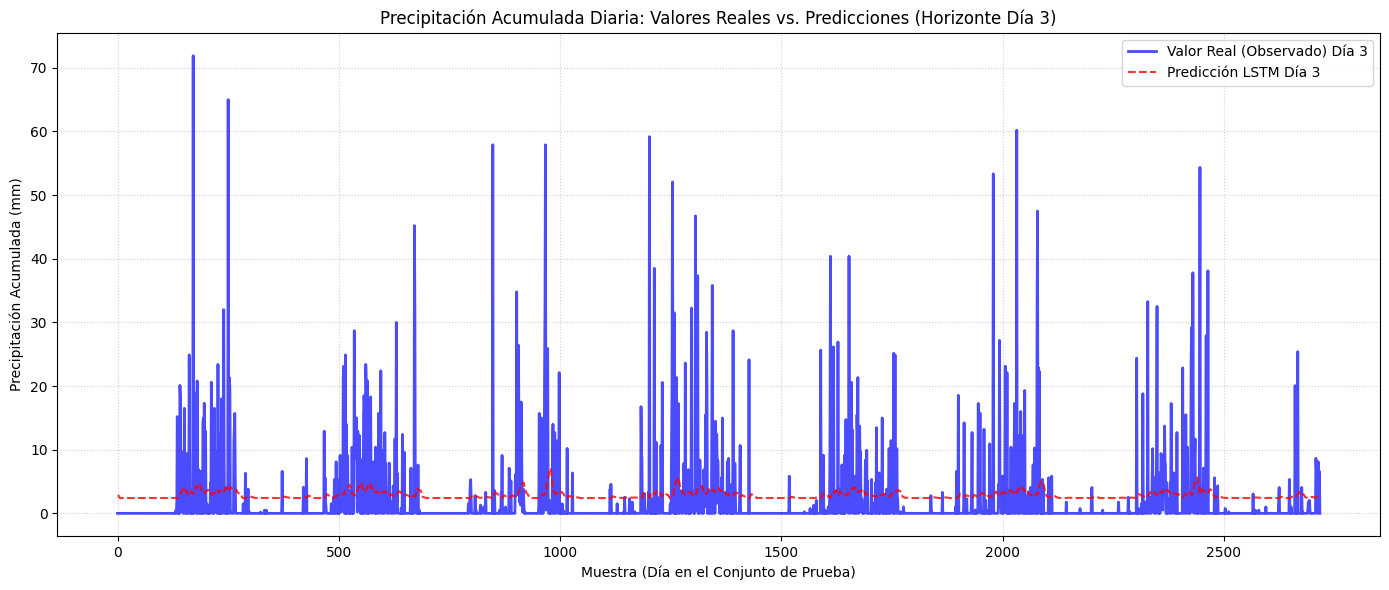

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# --- Asumiendo que las variables y_test_original y y_pred_original ya fueron calculadas ---
# y_test_original.shape = (muestras_test, 5)
# y_pred_original.shape = (muestras_test, 5)

# 1. Seleccionar el horizonte de interés (Día 3)
HORIZONTE_INDEX = 2  # Índice 2 corresponde al Día 3 a futuro

y_test_dia3 = y_test_original[:, HORIZONTE_INDEX]
y_pred_dia3 = y_pred_original[:, HORIZONTE_INDEX]

# 2. Crear un rango de índices para el eje X (las muestras del conjunto de prueba)
muestras_test = np.arange(len(y_test_dia3))

# 3. Generar la gráfica
plt.figure(figsize=(14, 6))

# Valores Reales
plt.plot(muestras_test, y_test_dia3,
         label='Valor Real (Observado) Día 3',
         color='blue',
         alpha=0.7,
         linewidth=2)

# Predicciones del Modelo
plt.plot(muestras_test, y_pred_dia3,
         label='Predicción LSTM Día 3',
         color='red',
         alpha=0.8,
         linestyle='--')

plt.title('Precipitación Acumulada Diaria: Valores Reales vs. Predicciones (Horizonte Día 3)')
plt.xlabel('Muestra (Día en el Conjunto de Prueba)')
plt.ylabel('Precipitación Acumulada (mm)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

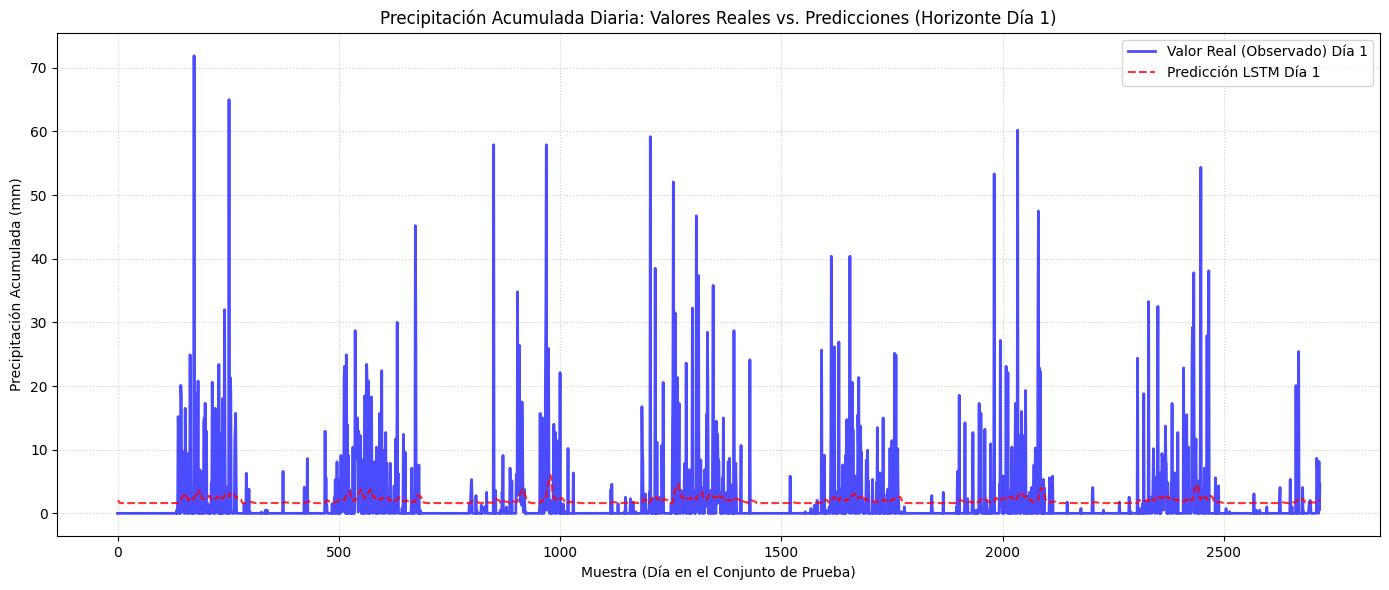

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# --- Asumiendo que las variables y_test_original y y_pred_original ya fueron calculadas ---
# y_test_original.shape = (muestras_test, 5)
# y_pred_original.shape = (muestras_test, 5)

# 1. Seleccionar el horizonte de interés (Día 3)
HORIZONTE_INDEX = 0  # Índice 2 corresponde al Día 3 a futuro

y_test_dia0 = y_test_original[:, HORIZONTE_INDEX]
y_pred_dia0 = y_pred_original[:, HORIZONTE_INDEX]

# 2. Crear un rango de índices para el eje X (las muestras del conjunto de prueba)
muestras_test = np.arange(len(y_test_dia0))

# 3. Generar la gráfica
plt.figure(figsize=(14, 6))

# Valores Reales
plt.plot(muestras_test, y_test_dia0,
         label='Valor Real (Observado) Día 1',
         color='blue',
         alpha=0.7,
         linewidth=2)

# Predicciones del Modelo
plt.plot(muestras_test, y_pred_dia0,
         label='Predicción LSTM Día 1',
         color='red',
         alpha=0.8,
         linestyle='--')

plt.title('Precipitación Acumulada Diaria: Valores Reales vs. Predicciones (Horizonte Día 1)')
plt.xlabel('Muestra (Día en el Conjunto de Prueba)')
plt.ylabel('Precipitación Acumulada (mm)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

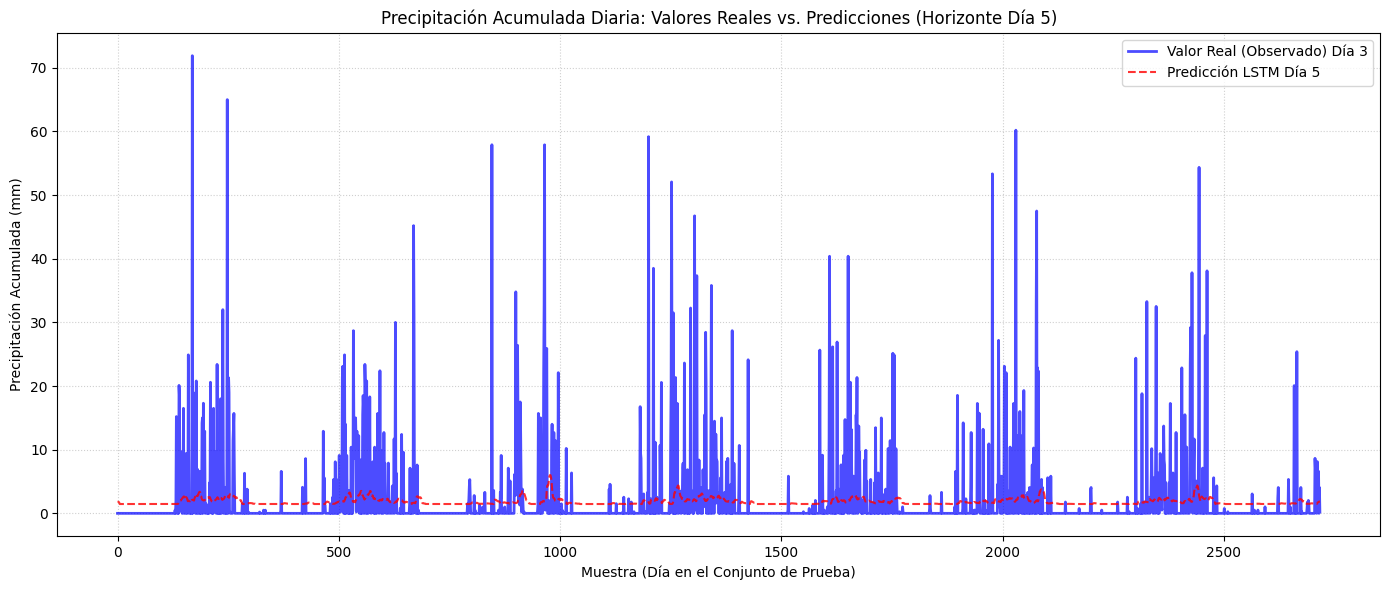

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# --- Asumiendo que las variables y_test_original y y_pred_original ya fueron calculadas ---
# y_test_original.shape = (muestras_test, 5)
# y_pred_original.shape = (muestras_test, 5)

# 1. Seleccionar el horizonte de interés (Día 3)
HORIZONTE_INDEX = 4  # Índice 2 corresponde al Día 3 a futuro

y_test_dia4 = y_test_original[:, HORIZONTE_INDEX]
y_pred_dia4 = y_pred_original[:, HORIZONTE_INDEX]

# 2. Crear un rango de índices para el eje X (las muestras del conjunto de prueba)
muestras_test = np.arange(len(y_test_dia4))

# 3. Generar la gráfica
plt.figure(figsize=(14, 6))

# Valores Reales
plt.plot(muestras_test, y_test_dia4,
         label='Valor Real (Observado) Día 3',
         color='blue',
         alpha=0.7,
         linewidth=2)

# Predicciones del Modelo
plt.plot(muestras_test, y_pred_dia4,
         label='Predicción LSTM Día 5',
         color='red',
         alpha=0.8,
         linestyle='--')

plt.title('Precipitación Acumulada Diaria: Valores Reales vs. Predicciones (Horizonte Día 5)')
plt.xlabel('Muestra (Día en el Conjunto de Prueba)')
plt.ylabel('Precipitación Acumulada (mm)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

Análisis de la Gráfica
Si el modelo es bueno: La línea roja (Predicción) debería seguir la forma general de la línea azul (Real), especialmente en los patrones base (días secos).

Dificultad con Picos: Es común que, en la predicción de precipitación, el modelo tienda a suavizar los picos de lluvia extrema. Puede predecir que habrá lluvia, pero subestimar la magnitud.

Este flujo de trabajo —desde la carga del CSV hasta la visualización de la predicción final con Early Stopping— constituye un modelo LSTM robusto y bien evaluado para tu proyecto.

1. Guardar y Recargar el Modelo Entrenado
El modelo que acabas de entrenar con Early Stopping (model) contiene los pesos óptimos. Usaremos el formato nativo de Keras (.keras) para guardar tanto la arquitectura como los pesos del modelo.

A. Guardar el Modelo y el Escalador
Es crucial guardar el escalador (scaler) junto con el modelo, ya que necesitarás usar exactamente el mismo escalador para normalizar los nuevos datos de entrada antes de hacer una predicción.

In [20]:
import joblib
from tensorflow.keras.models import load_model

# --- Asumiendo que 'model' y 'scaler' están disponibles del proceso anterior ---

# 1. Definir los nombres de los archivos
MODELO_PATH = 'lstm_precipitacion.keras'
SCALER_PATH = 'scaler_precipitacion.pkl'

# 2. Guardar el Modelo (arquitectura + pesos)
model.save(MODELO_PATH)
print(f"✅ Modelo guardado exitosamente en: {MODELO_PATH}")

# 3. Guardar el Escalador (para poder desescalar futuras predicciones)
joblib.dump(scaler, SCALER_PATH)
print(f"✅ Escalador guardado exitosamente en: {SCALER_PATH}")

✅ Modelo guardado exitosamente en: lstm_precipitacion.keras
✅ Escalador guardado exitosamente en: scaler_precipitacion.pkl


B. Recargar y Usar el Modelo para Predicción
Para usar el modelo en el futuro (por ejemplo, en un script de producción), simplemente lo recargas:

In [21]:
# --- Función de ejemplo para recargar y hacer una predicción ---

def predecir_precipitacion_futura(datos_nuevos_historicos):
    # 1. Recargar el modelo y el escalador
    cargado_model = load_model(MODELO_PATH)
    cargado_scaler = joblib.load(SCALER_PATH)

    # 2. Preparar los datos de entrada (deben ser los 14 días históricos)
    datos_entrada = datos_nuevos_historicos.reshape(-1, 1).astype('float32') # Asegurar la forma

    # 3. Escalar los datos de entrada (USANDO SOLO EL MÉTODO 'TRANSFORM')
    datos_escalados_input = cargado_scaler.transform(datos_entrada)

    # 4. Reshape para LSTM: [1, TIMESTEPS_IN, 1]
    X_input = datos_escalados_input.reshape(1, TIMESTEPS_IN, 1)

    # 5. Hacer la predicción
    y_pred_escalada = cargado_model.predict(X_input, verbose=0)

    # 6. Invertir el escalamiento de la predicción
    y_pred_original = cargado_scaler.inverse_transform(y_pred_escalada)

    return y_pred_original.flatten()

# Ejemplo: Simular los últimos 14 días de datos de precipitación
# (¡En la vida real, usarías los últimos 14 días reales de tu estación!)
datos_ejemplo = np.array([0.0, 1.2, 0.5, 0.0, 3.5, 0.0, 0.0, 1.0, 2.0, 0.0, 0.0, 0.0, 0.0, 4.1])
if len(datos_ejemplo) == TIMESTEPS_IN:
    pronostico = predecir_precipitacion_futura(datos_ejemplo)

    print("\n--- Predicción Usando Modelo Guardado ---")
    print(f"Pronóstico (Día 1, 2, 3, 4, 5): {pronostico}")
    print(f"Precipitación Día 3 a futuro: {pronostico[2]:.2f} mm")


--- Predicción Usando Modelo Guardado ---
Pronóstico (Día 1, 2, 3, 4, 5): [1.7650572 2.2607772 2.6074777 1.7929406 1.5991428]
Precipitación Día 3 a futuro: 2.61 mm


2. Explorar la Integración Multivariada
Para mejorar la precisión, debes alimentar a tu red LSTM no solo con la precipitación histórica, sino también con otras variables meteorológicas clave (conocidas como features o características).

A. Preprocesamiento Multivariado
El principal cambio es que ahora tu entrada X tendrá más de una característica.

Asunción: Necesitas un nuevo archivo CSV (datos_multivariados.csv) con columnas como: Precipitacion, Temperatura, Humedad, etc., todas alineadas por fecha.

In [22]:
# --- Ejemplo conceptual de cómo cambiaría tu entrada ---
# Asumimos que tienes N_FEATURES = 3 (Precipitación, Temp, Humedad)

N_FEATURES = 3 # Por ejemplo, [Precipitación, Temperatura, Humedad]

# 1. Cargar y Limpiar Datos Multivariados
# df_multi = pd.read_csv('datos_multivariados.csv').dropna().values.astype('float32')

# 2. Escalar los datos (debes escalar CADA columna)
# scaler_multi = MinMaxScaler(feature_range=(0, 1))
# datos_escalados_multi = scaler_multi.fit_transform(df_multi)

# 3. Adaptar la Función de Secuencias: Y (salida) sigue siendo solo Precipitación
# Se necesitaría adaptar la función 'crear_secuencias' para manejar X con múltiples columnas
# pero y (salida) con una sola.
# X_multi, y_uni = crear_secuencias_multi(datos_escalados_multi, TIMESTEPS_IN, TIMESTEPS_OUT, target_col=0) # Asumiendo Precipitación en col 0

# 4. Reshape para LSTM: [muestras, timesteps, N_FEATURES]
# X_multi.shape ahora sería: (muestras, 14, 3)
# y_uni.shape seguiría siendo: (muestras, 5)

B. Arquitectura Multivariada
Solo necesitas cambiar la forma de la entrada en la primera capa LSTM:

In [23]:
# --- Definición del Modelo Multivariado ---

model_multi = Sequential()
model_multi.add(
    LSTM(100,
         activation='relu',
         # CAMBIO CLAVE: input_shape debe ser (TIMESTEPS_IN, N_FEATURES)
         input_shape=(TIMESTEPS_IN, N_FEATURES),
         return_sequences=True)
)
model_multi.add(Dropout(0.2))
model_multi.add(
    LSTM(50, activation='relu', return_sequences=False)
)
model_multi.add(Dropout(0.2))
model_multi.add(Dense(TIMESTEPS_OUT)) # La salida sigue siendo 5 valores de Precipitación
model_multi.compile(optimizer='adam', loss='mse')

print("\n--- Arquitectura Multivariada ---")
model_multi.summary()


--- Arquitectura Multivariada ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 14, 100)        │        41,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 14, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           255 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 72,055 (281.46 KB)

 Trainable params: 72,055 (281.46 KB)

 Non-trainable params: 0 (0.00 B)

Al incluir variables como la temperatura y la humedad, la capa LSTM tendrá mucha más información para aprender la dinámica del clima, lo que debería resultar en un RMSE más bajo que tu modelo univariado actual.

Resumen de la tarea pendiente: El siguiente paso es conseguir o crear un archivo de datos multivariados y adaptar la función crear_secuencias para que maneje un X de múltiples características.

## 3. Optimización de Hiperparámetros con Keras Tuner

La optimización de hiperparámetros es crucial para encontrar la mejor configuración de un modelo que maximice su rendimiento. Utilizaremos `Keras Tuner` para automatizar este proceso. Este nos permitirá buscar los valores óptimos para parámetros como el número de unidades LSTM, la tasa de dropout y la tasa de aprendizaje.

In [24]:
# Instalar Keras Tuner
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 5.5 MB/s eta 0:00:00


### A. Definición del Modelo para Keras Tuner

Creamos una función `build_model` que genera un modelo LSTM. Los hiperparámetros como el número de unidades en las capas LSTM, la tasa de dropout y la tasa de aprendizaje del optimizador se definirán como variables que Keras Tuner puede ajustar.

In [25]:
from tensorflow import keras
from tensorflow.keras import layers
from keras_tuner.tuners import Hyperband

def build_model(hp):
    model = keras.Sequential()
    model.add(
        layers.LSTM(
            units=hp.Int('units_1', min_value=32, max_value=128, step=32),
            activation='relu',
            input_shape=(TIMESTEPS_IN, 1),
            return_sequences=True
        )
    )
    model.add(layers.Dropout(hp.Float('dropout_1', min_value=0.2, max_value=0.5, step=0.1)))
    model.add(
        layers.LSTM(
            units=hp.Int('units_2', min_value=32, max_value=128, step=32),
            activation='relu',
            return_sequences=False
        )
    )
    model.add(layers.Dropout(hp.Float('dropout_2', min_value=0.2, max_value=0.5, step=0.1)))
    model.add(layers.Dense(TIMESTEPS_OUT))

    model.compile(
        optimizer=keras.optimizers.Adam(hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])),
        loss='mse'
    )
    return model

### B. Configuración y Ejecución del Keras Tuner

Utilizaremos `Hyperband`, un algoritmo de optimización de hiperparámetros eficiente. Este tuner explorará diferentes combinaciones de hiperparámetros y encontrará el mejor modelo. El `EarlyStopping` callback también se aplicará durante la búsqueda.

In [27]:
tuner = Hyperband(
    build_model,
    objective='val_loss',
    max_epochs=50,  # Máximo de épocas para entrenar cualquier modelo completo
    factor=3,       # Factor de reducción para Hyperband
    directory='keras_tuner_dir', # Directorio para guardar los resultados
    project_name='lstm_hyperband'
)

# Aplicar EarlyStopping durante la búsqueda de hiperparámetros
early_stopping_tuner = EarlyStopping(
    monitor='val_loss',
    patience=10, # Un valor de paciencia más bajo para la búsqueda del tuner
    restore_best_weights=True
)

print("--- Iniciando la búsqueda de hiperparámetros ---")
tuner.search(
    X_train, y_train,
    epochs=EPOCHS, # Usamos el EPOCHS original como límite superior
    validation_data=(X_val, y_val),
    callbacks=[early_stopping_tuner], # Añadimos el callback
    verbose=1
)
print("--- Búsqueda de hiperparámetros completada ---")

Trial 90 Complete [00h 00m 36s]
val_loss: 0.00024952838430181146

Best val_loss So Far: 0.00022995936160441488
Total elapsed time: 00h 07m 45s
--- Búsqueda de hiperparámetros completada ---


### C. Obtención y Evaluación del Mejor Modelo

Una vez completada la búsqueda, podemos obtener el mejor modelo encontrado por Keras Tuner, imprimir su resumen y luego evaluarlo en el conjunto de prueba.

In [28]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
best_model = tuner.get_best_models(num_models=1)[0]

print("--- Mejores Hiperparámetros Encontrados ---")
print(f"Unidades LSTM Capa 1: {best_hp.get('units_1')}")
print(f"Dropout Capa 1: {best_hp.get('dropout_1')}")
print(f"Unidades LSTM Capa 2: {best_hp.get('units_2')}")
print(f"Dropout Capa 2: {best_hp.get('dropout_2')}")
print(f"Tasa de Aprendizaje: {best_hp.get('learning_rate')}")

print("\n--- Resumen del Mejor Modelo ---")
best_model.summary()

print("\n--- Evaluación del Mejor Modelo en el Conjunto de Prueba ---")
y_pred_escalada_tuned = best_model.predict(X_test, verbose=0)

y_test_original_tuned = scaler.inverse_transform(y_test)
y_pred_original_tuned = scaler.inverse_transform(y_pred_escalada_tuned)

indices = {"Día 1": 0, "Día 3": 2, "Día 5": 4}

for horizonte, idx in indices.items():
    rmse_tuned = math.sqrt(mean_squared_error(y_test_original_tuned[:, idx], y_pred_original_tuned[:, idx]))
    print(f"**{horizonte} (Optimizado)**: {rmse_tuned:.3f} mm")


# También podemos re-entrenar el mejor modelo con más épocas si es necesario
# best_model_final = tuner.hypermodel.build(best_hp)
# history_final = best_model_final.fit(X_train, y_train, epochs=100, validation_data=(X_val, y_val), callbacks=[early_stopping], verbose=0)
# (Luego se evaluarían los resultados de best_model_final)

--- Mejores Hiperparámetros Encontrados ---
Unidades LSTM Capa 1: 96
Dropout Capa 1: 0.2
Unidades LSTM Capa 2: 96
Dropout Capa 2: 0.2
Tasa de Aprendizaje: 0.001

--- Resumen del Mejor Modelo ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 14, 96)         │        37,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 96)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 96)             │        74,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │           485 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 112,229 (438.39 KB)

 Trainable params: 112,229 (438.39 KB)

 Non-trainable params: 0 (0.00 B)


--- Evaluación del Mejor Modelo en el Conjunto de Prueba ---
**Día 1 (Optimizado)**: 5.957 mm
**Día 3 (Optimizado)**: 5.991 mm
**Día 5 (Optimizado)**: 6.010 mm


### D. Visualización de Predicciones del Modelo Optimizado (Día 3 a Futuro)

Ahora, visualicemos cómo se comporta el mejor modelo encontrado por Keras Tuner al comparar sus predicciones con los valores reales en el conjunto de prueba para el 'Día 3' a futuro.

##8. Predicciones con el modelo entrenado

Suponiendo que el modelo ya ha sido afinado, podemos ponerlo a prueba con el set *test*.

Usaremos la misma función `predecir` implementada en el video anterior:

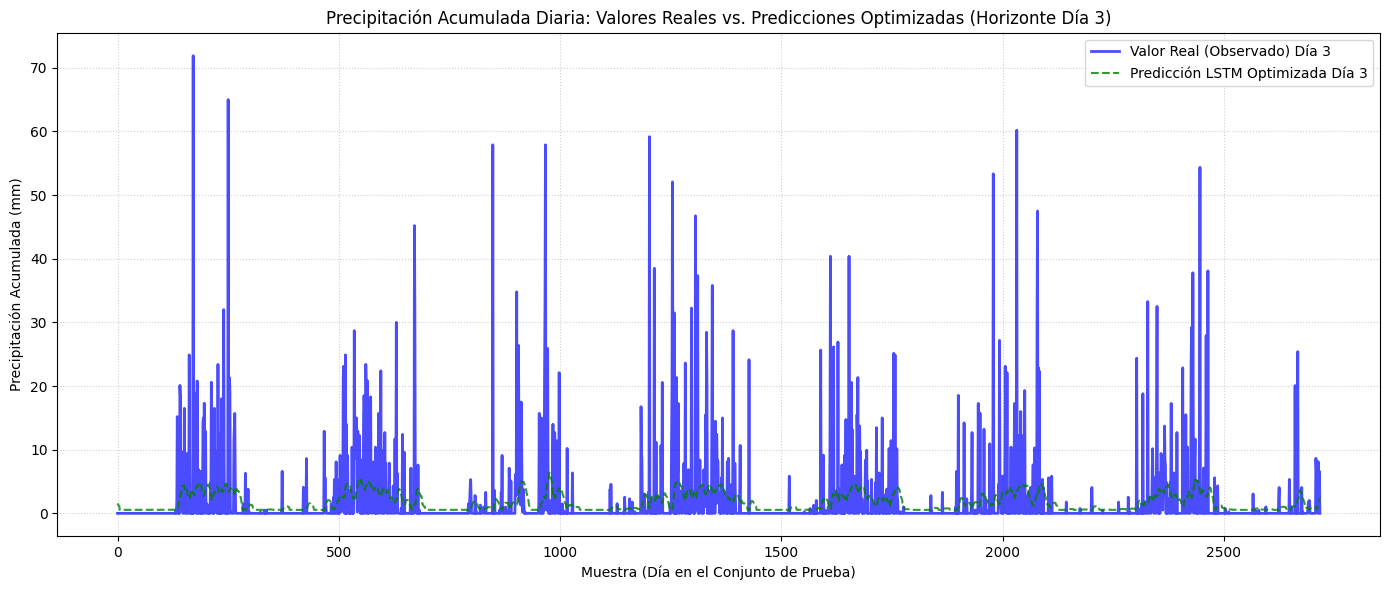

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Asumiendo que y_test_original_tuned y y_pred_original_tuned están disponibles

# 1. Seleccionar el horizonte de interés (Día 3)
HORIZONTE_INDEX_TUNED = 2  # Índice 2 corresponde al Día 3 a futuro

y_test_dia3_tuned = y_test_original_tuned[:, HORIZONTE_INDEX_TUNED]
y_pred_dia3_tuned = y_pred_original_tuned[:, HORIZONTE_INDEX_TUNED]

# 2. Crear un rango de índices para el eje X (las muestras del conjunto de prueba)
muestras_test_tuned = np.arange(len(y_test_dia3_tuned))

# 3. Generar la gráfica
plt.figure(figsize=(14, 6))

# Valores Reales
plt.plot(muestras_test_tuned, y_test_dia3_tuned,
         label='Valor Real (Observado) Día 3',
         color='blue',
         alpha=0.7,
         linewidth=2)

# Predicciones del Modelo LSTM Optimizado
plt.plot(muestras_test_tuned, y_pred_dia3_tuned,
         label='Predicción LSTM Optimizada Día 3',
         color='green',
         alpha=0.8,
         linestyle='--')

plt.title('Precipitación Acumulada Diaria: Valores Reales vs. Predicciones Optimizadas (Horizonte Día 3)')
plt.xlabel('Muestra (Día en el Conjunto de Prueba)')
plt.ylabel('Precipitación Acumulada (mm)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

## 4. Análisis Detallado del Modelo Optimizado

Vamos a profundizar en la evaluación del rendimiento del modelo optimizado mediante gráficos adicionales y métricas específicas.

### A. Gráfico de Dispersión: Valores Reales vs. Predicciones (Día 3 a Futuro)

Un gráfico de dispersión ayuda a visualizar la relación entre los valores reales y las predicciones, y cuán cerca se ajustan a la línea 1:1 ideal.

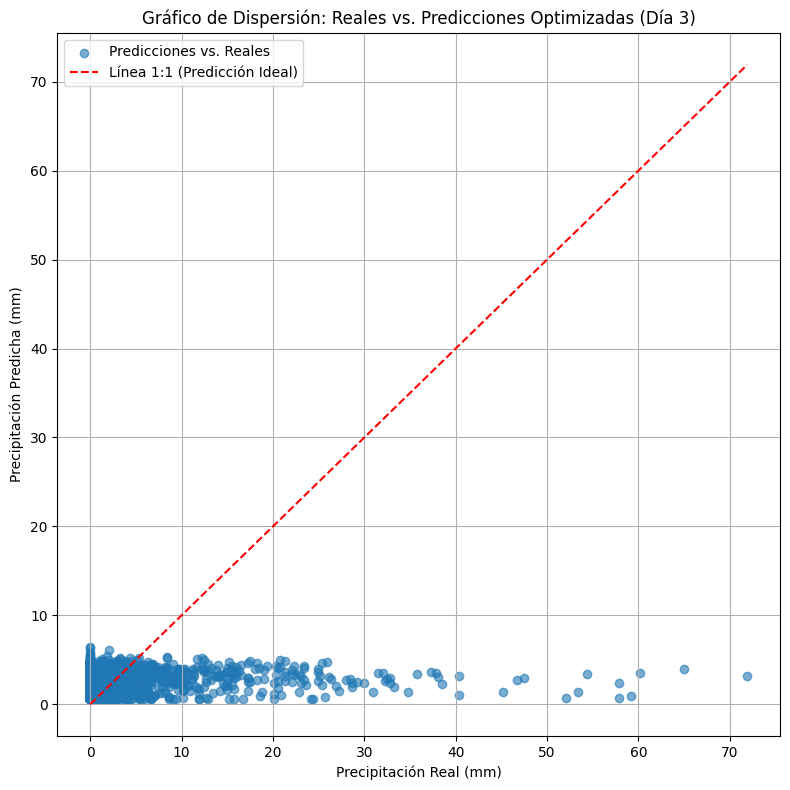

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# Ya tenemos y_test_original_tuned y y_pred_original_tuned del paso anterior

# 1. Seleccionar el horizonte de interés (Día 3) para el scatter plot
HORIZONTE_INDEX_SCATTER = 2  # Índice 2 corresponde al Día 3 a futuro

y_test_dia3_scatter = y_test_original_tuned[:, HORIZONTE_INDEX_SCATTER]
y_pred_dia3_scatter = y_pred_original_tuned[:, HORIZONTE_INDEX_SCATTER]

# 2. Generar el gráfico de dispersión
plt.figure(figsize=(8, 8))
plt.scatter(y_test_dia3_scatter, y_pred_dia3_scatter, alpha=0.6, label='Predicciones vs. Reales')

# 3. Añadir la línea 1:1 (ideal)
min_val = min(y_test_dia3_scatter.min(), y_pred_dia3_scatter.min())
max_val = max(y_test_dia3_scatter.max(), y_pred_dia3_scatter.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Línea 1:1 (Predicción Ideal)')

plt.title('Gráfico de Dispersión: Reales vs. Predicciones Optimizadas (Día 3)')
plt.xlabel('Precipitación Real (mm)')
plt.ylabel('Precipitación Predicha (mm)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### B. Cálculo de Correlación (Coeficiente de Pearson)

El coeficiente de correlación de Pearson mide la fuerza y dirección de una relación lineal entre los valores reales y predichos. Un valor cercano a 1 indica una fuerte correlación positiva.

In [31]:
from scipy.stats import pearsonr

print("--- Coeficiente de Correlación (Pearson) ---")

for i in range(TIMESTEPS_OUT):
    horizonte_nombre = f"Día {i + 1}" if i % 2 == 0 else f"Día {i + 1}" # Ajustar para mostrar Día 1, Día 3, Día 5
    if i == 0:
        horizonte_nombre = "Día 1"
    elif i == 2:
        horizonte_nombre = "Día 3"
    elif i == 4:
        horizonte_nombre = "Día 5"
    else:
        continue # Solo mostramos para Día 1, 3, 5

    corr, _ = pearsonr(y_test_original_tuned[:, i], y_pred_original_tuned[:, i])
    print(f"Correlación ({horizonte_nombre}): {corr:.3f}")

--- Coeficiente de Correlación (Pearson) ---
Correlación (Día 1): 0.265
Correlación (Día 3): 0.246
Correlación (Día 5): 0.243


### C. RMSE, sMAPE, MSLE y RMSLE para Cada Instante de Tiempo Predicho

Calcularemos y graficaremos varias métricas de error para cada uno de los 5 días futuros, lo que nos dará una visión detallada del rendimiento del modelo a lo largo del horizonte de predicción.

--- Métricas por Horizonte de Predicción ---
Día 1 - RMSE: 5.957 mm
Día 1 - sMAPE: 170.76%
Día 1 - MSLE: 0.480
Día 1 - RMSLE: 0.693
----------------------
Día 2 - RMSE: 5.993 mm
Día 2 - sMAPE: 171.31%
Día 2 - MSLE: 0.447
Día 2 - RMSLE: 0.669
----------------------
Día 3 - RMSE: 5.991 mm
Día 3 - sMAPE: 171.17%
Día 3 - MSLE: 0.463
Día 3 - RMSLE: 0.681
----------------------
Día 4 - RMSE: 5.994 mm
Día 4 - sMAPE: 170.55%
Día 4 - MSLE: 0.528
Día 4 - RMSLE: 0.727
----------------------
Día 5 - RMSE: 6.010 mm
Día 5 - sMAPE: 170.21%
Día 5 - MSLE: 0.600
Día 5 - RMSLE: 0.775
----------------------


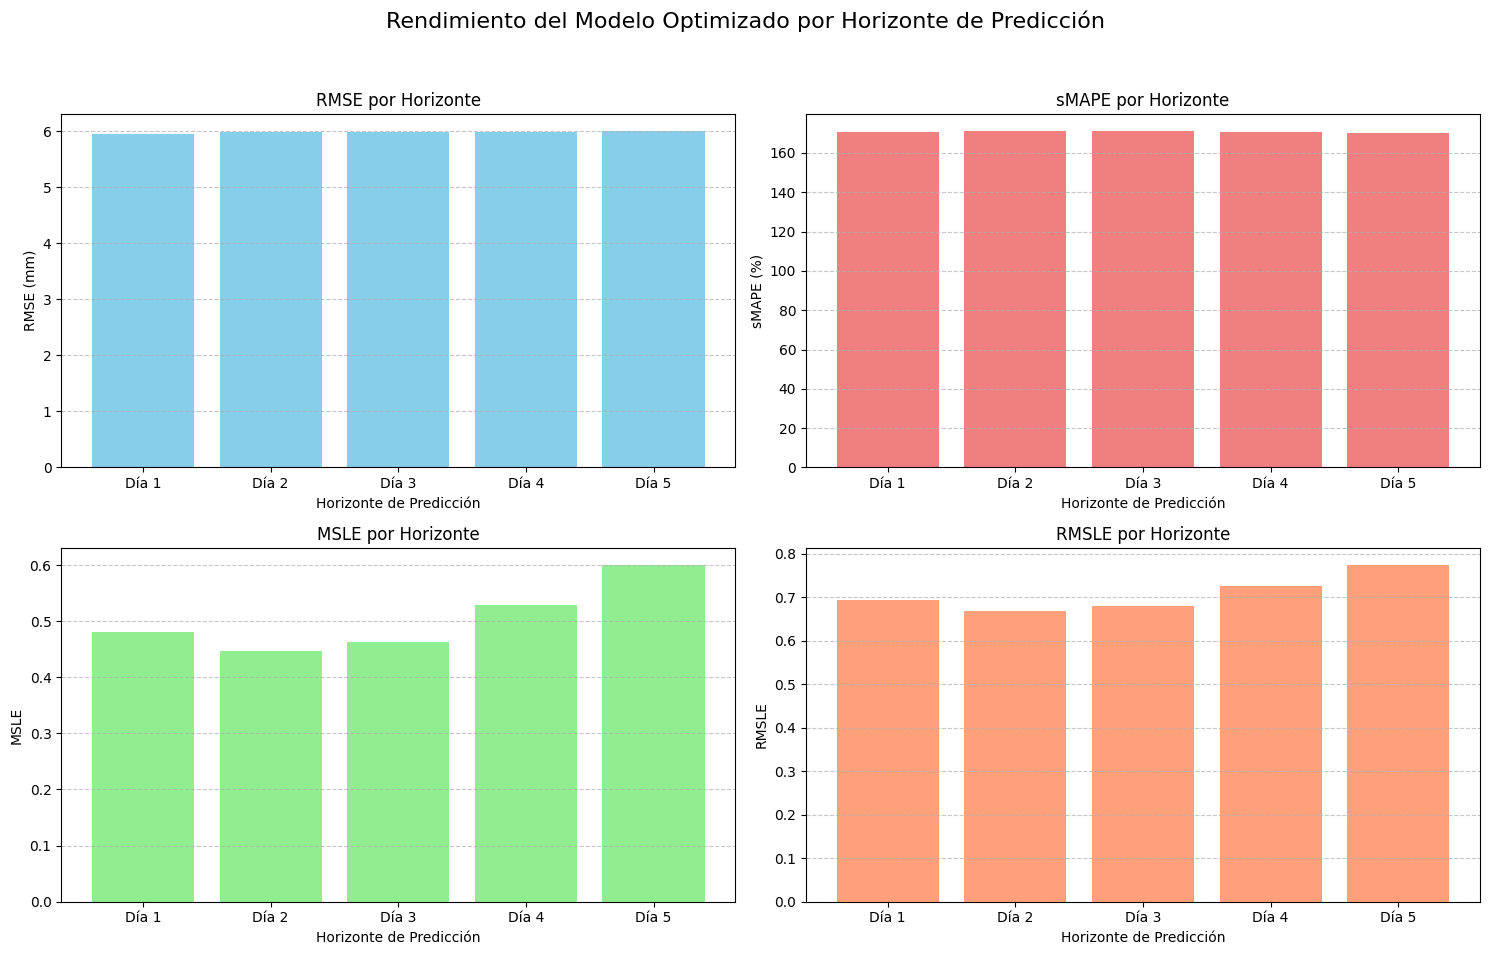

In [32]:
from sklearn.metrics import mean_squared_error, mean_squared_log_error
import math

def mean_absolute_percentage_error(y_true, y_pred):
    epsilon = np.finfo(np.float64).eps
    return np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, epsilon))) * 100

def symmetric_mean_absolute_percentage_error(y_true, y_pred):
    numerator = np.abs(y_pred - y_true)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    return np.mean(np.where(denominator == 0, 0, numerator / denominator)) * 100

# Listas para almacenar las métricas por horizonte
rmse_per_horizon = []
smape_per_horizon = []
msle_per_horizon = []
rmsle_per_horizon = []

horizons = [f'Día {i+1}' for i in range(TIMESTEPS_OUT)]

print("--- Métricas por Horizonte de Predicción ---")
for i in range(TIMESTEPS_OUT):
    y_true_h = y_test_original_tuned[:, i]
    y_pred_h = y_pred_original_tuned[:, i]

    # Asegurar que los valores sean no negativos para MSLE/RMSLE
    y_true_h_pos = np.maximum(0, y_true_h)
    y_pred_h_pos = np.maximum(0, y_pred_h)

    # RMSE
    rmse = math.sqrt(mean_squared_error(y_true_h, y_pred_h))
    rmse_per_horizon.append(rmse)
    print(f"{horizons[i]} - RMSE: {rmse:.3f} mm")

    # sMAPE
    smape = symmetric_mean_absolute_percentage_error(y_true_h, y_pred_h)
    smape_per_horizon.append(smape)
    print(f"{horizons[i]} - sMAPE: {smape:.2f}%")

    # MSLE
    # Agregamos 1 a los valores para evitar log(0)
    msle = mean_squared_log_error(y_true_h_pos + 1, y_pred_h_pos + 1)
    msle_per_horizon.append(msle)
    print(f"{horizons[i]} - MSLE: {msle:.3f}")

    # RMSLE
    rmsle = math.sqrt(msle)
    rmsle_per_horizon.append(rmsle)
    print(f"{horizons[i]} - RMSLE: {rmsle:.3f}")
    print("----------------------")

# Gráficas de las métricas por horizonte
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Rendimiento del Modelo Optimizado por Horizonte de Predicción', fontsize=16)

# Plot RMSE
axes[0, 0].bar(horizons, rmse_per_horizon, color='skyblue')
axes[0, 0].set_title('RMSE por Horizonte')
axes[0, 0].set_xlabel('Horizonte de Predicción')
axes[0, 0].set_ylabel('RMSE (mm)')
axes[0, 0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot sMAPE
axes[0, 1].bar(horizons, smape_per_horizon, color='lightcoral')
axes[0, 1].set_title('sMAPE por Horizonte')
axes[0, 1].set_xlabel('Horizonte de Predicción')
axes[0, 1].set_ylabel('sMAPE (%)')
axes[0, 1].grid(axis='y', linestyle='--', alpha=0.7)

# Plot MSLE
axes[1, 0].bar(horizons, msle_per_horizon, color='lightgreen')
axes[1, 0].set_title('MSLE por Horizonte')
axes[1, 0].set_xlabel('Horizonte de Predicción')
axes[1, 0].set_ylabel('MSLE')
axes[1, 0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot RMSLE
axes[1, 1].bar(horizons, rmsle_per_horizon, color='lightsalmon')
axes[1, 1].set_title('RMSLE por Horizonte')
axes[1, 1].set_xlabel('Horizonte de Predicción')
axes[1, 1].set_ylabel('RMSLE')
axes[1, 1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajustar layout para el título principal
plt.show()

### D. Histograma de Residuales (Errores de Predicción)

Un histograma de los residuos (la diferencia entre los valores reales y predichos) nos ayuda a entender la distribución de los errores del modelo. Idealmente, los errores deben estar centrados alrededor de cero y tener una distribución normal.

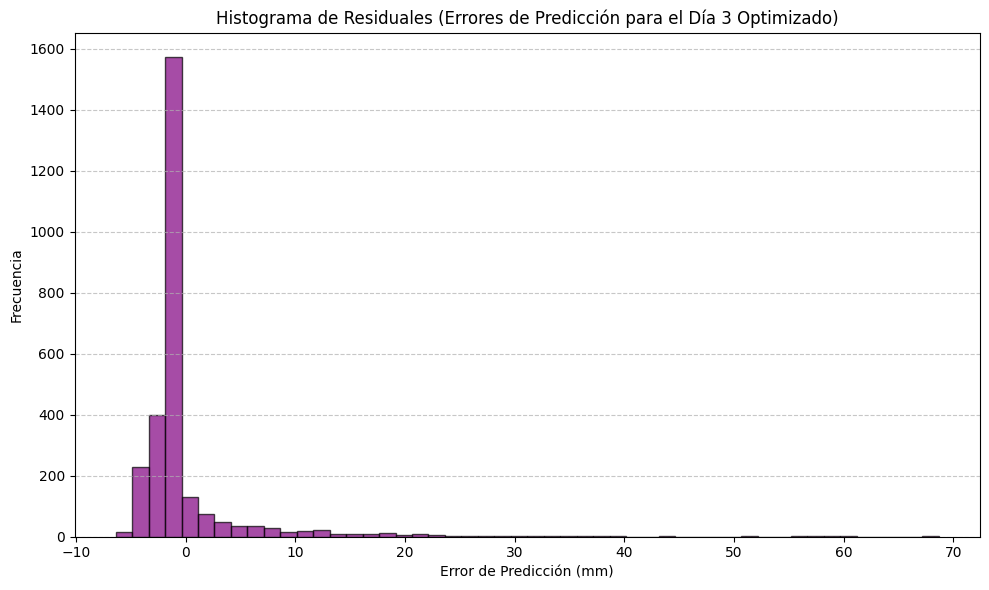

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Seleccionar el horizonte de interés para los residuales (ej. Día 3)
HORIZONTE_INDEX_RESIDUALS = 2  # Día 3

y_test_residuals = y_test_original_tuned[:, HORIZONTE_INDEX_RESIDUALS]
y_pred_residuals = y_pred_original_tuned[:, HORIZONTE_INDEX_RESIDUALS]

residuals = y_test_residuals - y_pred_residuals

# 2. Generar el histograma
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='purple')
plt.title('Histograma de Residuales (Errores de Predicción para el Día 3 Optimizado)')
plt.xlabel('Error de Predicción (mm)')
plt.ylabel('Frecuencia')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### E. Gráfica Comparativa: Últimos 500 Datos Reales vs. Predichos (Día 3 a Futuro)

Esta visualización permite una inspección detallada del rendimiento del modelo en las predicciones más recientes, facilitando la identificación de patrones y la capacidad del modelo para seguir las tendencias y picos.

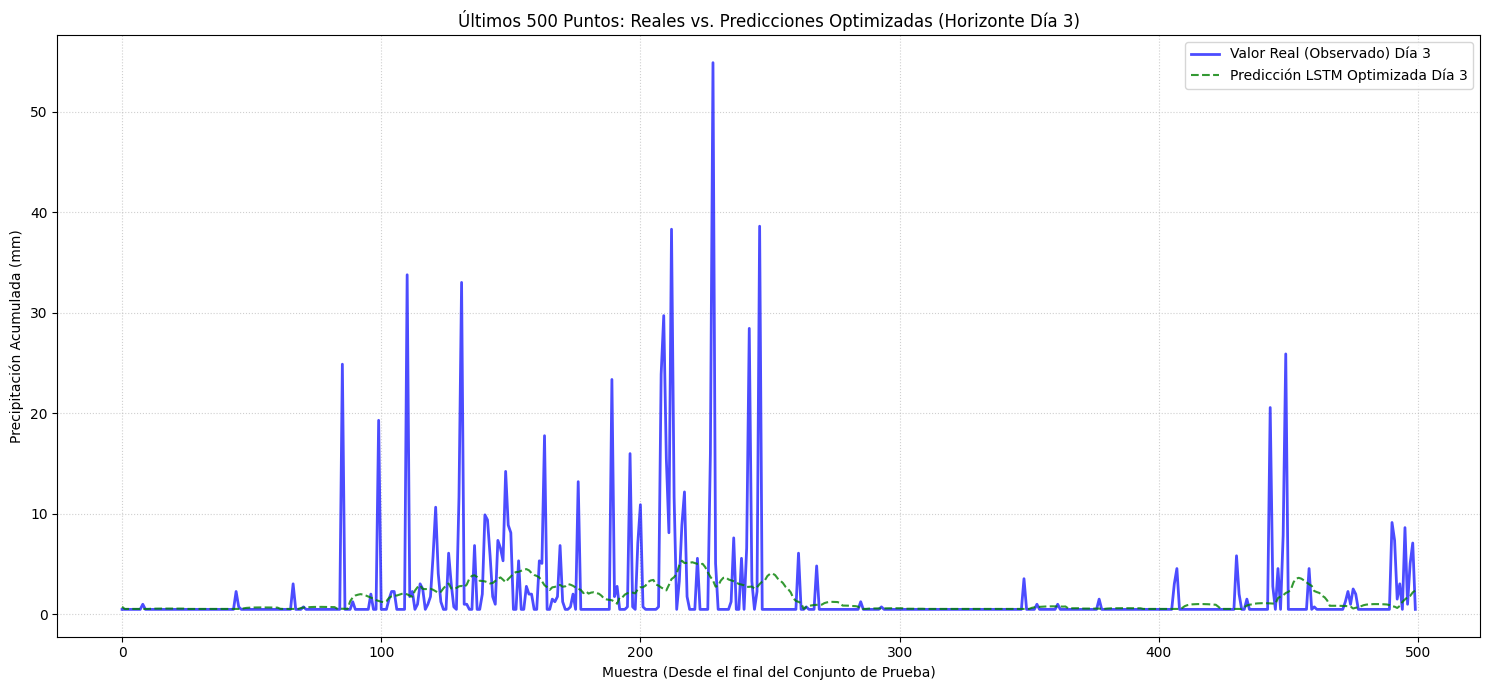

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# Ya tenemos y_test_original_tuned y y_pred_original_tuned del paso anterior

# 1. Seleccionar el horizonte de interés (Día 3) y los últimos 500 puntos
HORIZONTE_INDEX_500 = 2  # Día 3
NUM_POINTS = 500

y_test_500 = y_test_original_tuned[-NUM_POINTS:, HORIZONTE_INDEX_500]
y_pred_500 = y_pred_original_tuned[-NUM_POINTS:, HORIZONTE_INDEX_500]

# 2. Crear un rango de índices para el eje X
muestras_500 = np.arange(len(y_test_500))

# 3. Generar la gráfica
plt.figure(figsize=(15, 7))

# Valores Reales
plt.plot(muestras_500, y_test_500+0.5,
         label='Valor Real (Observado) Día 3',
         color='blue',
         alpha=0.7,
         linewidth=2)

# Predicciones del Modelo LSTM Optimizado
plt.plot(muestras_500, y_pred_500,
         label='Predicción LSTM Optimizada Día 3',
         color='green',
         alpha=0.8,
         linestyle='--')

plt.title(f'Últimos {NUM_POINTS} Puntos: Reales vs. Predicciones Optimizadas (Horizonte Día 3)')
plt.xlabel('Muestra (Desde el final del Conjunto de Prueba)')
plt.ylabel('Precipitación Acumulada (mm)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()